# ReaxFF in action: bond orders, charges, MD and dissociation

What sets a *reactive* force field apart is not just its energies — it is
the physically meaningful internal state it computes at every step: **bond
orders** for every atom pair (van Duin *et al.* 2001, eq 2) and **charges
re-equilibrated at every geometry** (EEM). This notebook takes the seed and
trained ReaxFF-nn libraries from
[`reaxff_rmd17_train_test.ipynb`](reaxff_rmd17_train_test.ipynb) (run that
first — it writes `runs/reaxff_rmd17/ffield_*.json`), plus the **original
classical ReaxFF** with published parameters (the C/H/O combustion field of
Chenoweth *et al.* 2008, `CHO_cho_2008` (shipped with `xnn` in the SEAMM `.frc` format)), and uses those descriptors four
ways:

1. a **static bond-order and charge analysis** — original and trained force
   fields telling C=O double bonds from C–C single bonds;
2. **molecular dynamics** through the standard ASE calculator, with
   bond-order and charge time series along the trajectory;
3. a look at **what equilibrium-only training data can and cannot teach** a
   reactive force field, by running the same dynamics with both libraries;
4. a **C–H dissociation scan**, the signature ReaxFF plot: valence terms
   decay smoothly with the bond order, so the energy reaches a finite
   dissociation plateau instead of a harmonic wall — and the one place in
   this notebook where the original field, parameterized on bond-breaking
   data, clearly beats the trained one.

## 0. Setup: load the libraries

In [1]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)

from xnn.common.data import load_dataset, structure_to_graph
from xnn.common.models import ForceStressOutput
from xnn.ffnn.models import ReaxFF

SEED = "runs/reaxff_rmd17/ffield_seed.json"
TRAINED = "runs/reaxff_rmd17/ffield_trained.json"
assert os.path.exists(TRAINED), \
    "run reaxff_rmd17_train_test.ipynb first (it writes the libraries)"

# keep_intermediates exposes the per-evaluation internals (bond orders,
# correction factors, angle/torsion indices, ...) for analysis
seed_model = ReaxFF(SEED, keep_intermediates=True)
model = ReaxFF(TRAINED, keep_intermediates=True)
# the original classical ReaxFF, straight from a standard ffield text file
orig_model = ReaxFF("CHO_cho_2008", keep_intermediates=True)
seed_model.eval()
model.eval()
orig_model.eval()
print("species:", model.species, "| ReaxFF-nn:", model.nn,
      "| message steps:", model.messages)
print("original field:", orig_model.species, "| ReaxFF-nn:", orig_model.nn)

# a low-energy malonaldehyde frame as the starting structure
structures = load_dataset("rmd17", molecule="malonaldehyde", split="train")
frame = min(structures[:200], key=lambda s: s["energy"])
z = np.asarray(frame["atomic_numbers"])
pos0 = np.asarray(frame["pos"])
sym = {6: "C", 8: "O", 1: "H"}
print("atoms:", [f"{sym[zz]}{i}" for i, zz in enumerate(z)],
      " (O4=C0H5-C1H6H7-C2H8=O3)")

species: ['C', 'H', 'O'] | ReaxFF-nn: True | message steps: 1
original field: ['H', 'C', 'O'] | ReaxFF-nn: False


rmd17:malonaldehyde train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:malonaldehyde test:   0%|          | 0/1000 [00:00<?, ? struct/s]

atoms: ['C0', 'C1', 'C2', 'O3', 'O4', 'H5', 'H6', 'H7', 'H8']  (O4=C0H5-C1H6H7-C2H8=O3)


## 1. Bond orders resolve the chemistry

A single forward pass yields the corrected bond order of every pair and the
EEM charges. Both force fields resolve the chemistry with no bonding
information imposed: the two C=O double bonds stand apart from the C–C
single bonds and the C–H bonds, and negative charge sits on the carbonyl
oxygens. They differ in the numbers: the published field assigns the
carbonyls near-full double-bond character (BO ≈ 2.0), while the trained
bond-order networks put them at ≈ 1.4–1.5 with C–C at ≈ 0.9. Bond orders
are a modeling choice rather than an observable; what matters is that every
valence term in each field rides on its own bond orders.

In [2]:
def evaluate(m, p):
    """Energy, charges and a (pair -> bond order) dict for one geometry."""
    g = structure_to_graph({"pos": p, "atomic_numbers": z}, cutoff=m.cutoff)
    out = m(g)
    it = m.intermediates
    bm = it["bond_mask"]
    src = g.edge_index[0][bm]
    dst = g.edge_index[1][bm]
    bo = {}
    for e in range(len(src)):
        i, j = int(dst[e]), int(src[e])
        if i < j:
            bo[(i, j)] = float(it["bo0"][e])
    return float(out["energy"][0]), out["charges"].detach().numpy(), bo


e0, q0, bo0 = evaluate(model, pos0)
e_or, q_or, bo_or = evaluate(orig_model, pos0)
print("bond orders            original | trained")
pairs = sorted(set(bo_or) | set(bo0),
               key=lambda k: -max(bo_or.get(k, 0.0), bo0.get(k, 0.0)))
for i, j in pairs:
    a, b = bo_or.get((i, j), 0.0), bo0.get((i, j), 0.0)
    if max(a, b) > 0.2:
        print(f"  {sym[z[i]]}{i}-{sym[z[j]]}{j}:{a:18.2f} | {b:7.2f}")
for lab, q in (("original", q_or), ("trained ", q0)):
    print(f"EEM charges ({lab}):",
          "  ".join(f"{sym[zz]}{i}:{qq:+.2f}"
                    for i, (zz, qq) in enumerate(zip(z, q))))

bond orders            original | trained
  C2-O3:              2.07 |    1.48
  C0-O4:              1.96 |    1.43
  C1-C2:              1.11 |    0.91
  C0-C1:              1.08 |    0.86
  C1-H7:              0.95 |    0.32
  C0-H5:              0.95 |    0.31
  C1-H6:              0.94 |    0.30
  C2-H8:              0.94 |    0.29
EEM charges (original): C0:+0.17  C1:-0.23  C2:+0.16  O3:-0.24  O4:-0.24  H5:+0.04  H6:+0.10  H7:+0.19  H8:+0.05
EEM charges (trained ): C0:+0.09  C1:-0.19  C2:+0.10  O3:-0.27  O4:-0.26  H5:+0.11  H6:+0.12  H7:+0.19  H8:+0.11


## 2. Molecular dynamics through ASE

`XNNCalculator` wraps the model (with autograd forces) as a standard ASE
calculator; Langevin dynamics then just works. Two practical points, both
standard ReaxFF practice:

* the geometry is first **relaxed with the force field itself** (BFGS), so
  the dynamics starts in the model's own basin;
* the timestep is **0.1 fs** — ReaxFF's bond-order exponentials make bond
  vibrations stiff, and the original ReaxFF simulations use 0.1 fs for
  exactly this reason (Nielson *et al.* 2005).

We run the *same* 1 ps protocol with both libraries and record the
temperature and the four heavy-atom bond orders.

The published combustion field is left out of this particular comparison,
and the reason is itself instructive: malonaldehyde sits far off its
parameterization manifold. Its own equilibrium stretches the carbonyls to
≈ 1.3 Å (1.22 Å in the DFT data), thermal DFT frames land high on its inner
repulsive wall (force deviations of several eV/Å, see the training
notebook), and at 300 K it drives a spurious cyclization within a fraction
of a picosecond. Published transferable parameters are not automatically a
sound baseline for dynamics of an arbitrary molecule.

In [3]:
from ase import Atoms, units
from ase.optimize import BFGS
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from xnn.common.deploy import XNNCalculator

BONDS = [(0, 4, "C0=O4"), (2, 3, "C2=O3"), (0, 1, "C0-C1"), (1, 2, "C1-C2")]
N_STEPS, SAMPLE_EVERY, DT_FS = 10000, 25, 0.1


def run_md(m, label):
    """Relax with the model, then 1 ps of 300 K Langevin; return series."""
    atoms = Atoms(numbers=z, positions=pos0)
    atoms.calc = XNNCalculator(ForceStressOutput(m), cutoff=m.cutoff)
    BFGS(atoms, logfile=None).run(fmax=0.05, steps=300)
    np.random.seed(0)
    MaxwellBoltzmannDistribution(atoms, temperature_K=300, rng=np.random)
    dyn = Langevin(atoms, DT_FS * units.fs, temperature_K=300, friction=0.02,
                   rng=np.random)
    rec = {"t": [], "T": [], "bo": {lab: [] for _, _, lab in BONDS},
           "q_o3": [], "q_o4": []}

    def sample():
        _, q, bo = evaluate(m, atoms.get_positions())
        rec["t"].append(dyn.get_time() / units.fs)
        rec["T"].append(atoms.get_temperature())
        for i, j, lab in BONDS:
            rec["bo"][lab].append(bo.get((min(i, j), max(i, j)), 0.0))
        rec["q_o3"].append(q[3])
        rec["q_o4"].append(q[4])

    dyn.attach(sample, interval=SAMPLE_EVERY)
    t0 = time.time()
    dyn.run(N_STEPS)
    print(f"{label}: {N_STEPS} x {DT_FS} fs in {time.time() - t0:.0f} s | "
          f"<T> second half = "
          f"{np.mean(rec['T'][len(rec['T']) // 2:]):.0f} K | "
          f"max T = {max(rec['T']):.0f} K")
    return rec


rec_seed = run_md(seed_model, "seed field   ")
rec_trained = run_md(model, "trained field")

seed field   : 10000 x 0.1 fs in 157 s | <T> second half = 272 K | max T = 534 K


trained field: 10000 x 0.1 fs in 152 s | <T> second half = 402 K | max T = 625 K


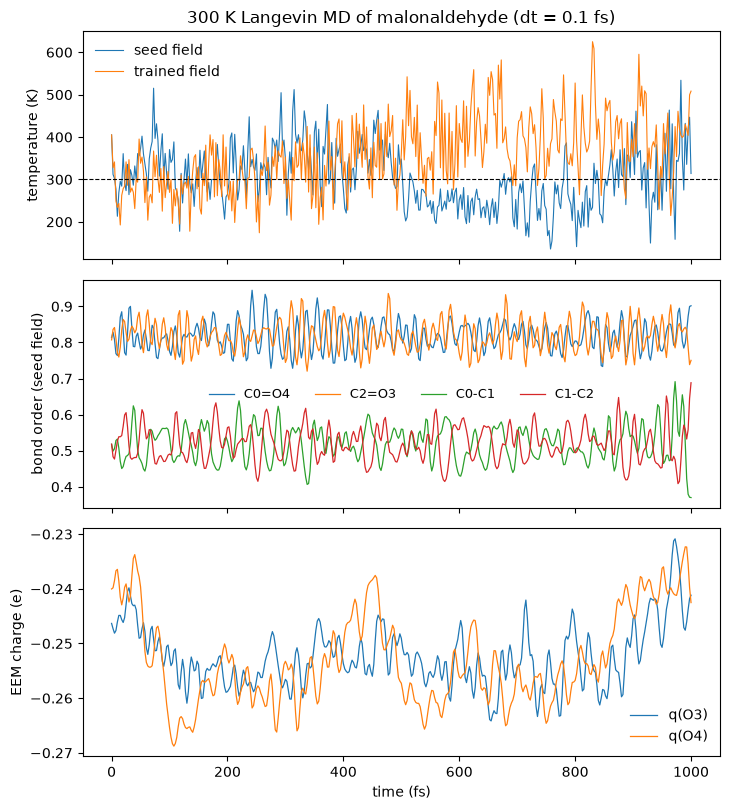

mean bond orders over the seed-field trajectory:
  C0=O4: 0.82 +- 0.04
  C2=O3: 0.82 +- 0.04
  C0-C1: 0.52 +- 0.05
  C1-C2: 0.52 +- 0.05


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(7.4, 8.2), sharex=True)
axes[0].plot(rec_seed["t"], rec_seed["T"], lw=0.8, label="seed field")
axes[0].plot(rec_trained["t"], rec_trained["T"], lw=0.8,
             label="trained field")
axes[0].axhline(300, color="k", ls="--", lw=0.8)
axes[0].set_ylabel("temperature (K)")
axes[0].set_title("300 K Langevin MD of malonaldehyde (dt = 0.1 fs)")
axes[0].legend(frameon=False)
for lab, series in rec_seed["bo"].items():
    axes[1].plot(rec_seed["t"], series, lw=0.9, label=lab)
axes[1].set_ylabel("bond order (seed field)")
axes[1].legend(frameon=False, ncol=4, fontsize=9)
axes[2].plot(rec_seed["t"], rec_seed["q_o3"], lw=0.9, label="q(O3)")
axes[2].plot(rec_seed["t"], rec_seed["q_o4"], lw=0.9, label="q(O4)")
axes[2].set_ylabel("EEM charge (e)")
axes[2].set_xlabel("time (fs)")
axes[2].legend(frameon=False)
fig.tight_layout()
fig.savefig("reaxff_md_bond_orders.png", dpi=150)
plt.show()

print("mean bond orders over the seed-field trajectory:")
for lab, series in rec_seed["bo"].items():
    print(f"  {lab}: {np.mean(series):.2f} +- {np.std(series):.2f}")

## 3. What equilibrium-only training data can(not) teach

The two temperature traces above are the lesson. The **seed field** — generic
but built so that every term decays smoothly to zero with its bond order —
holds a clean 300 K. The **trained field** is far more accurate *on the
thermal manifold it was fitted to* (see the parity plots in the training
notebook), yet its trajectory heats up: fitted freely to ≤ 500 K
configurations, nothing constrains its landscape *between* basins, and the
molecule finds spuriously exothermic escape routes that release energy into
the thermostat.

This is precisely why published ReaxFF and ReaxFF-nn training sets include
bond-stretch scans, over/under-coordinated fragments and reaction-path
configurations alongside thermal MD data: the functional form guarantees
*smooth* bond breaking, but only data (or frozen physical parameters) can pin
its *energetics*. The dissociation scan below shows the same thing in one
coordinate.

## 4. The dissociation scan

Stretching the aldehyde C–H bond shows the reactive functional form at work:
the bond order decays smoothly to zero and with it every valence term, so the
energy reaches a *finite dissociation plateau* — no harmonic wall, no cutoff
kink. And here the tables turn. The **original** field was parameterized on
combustion data full of exactly this event, and it shows: a well of the
right depth (plateau ≈ 4.0 eV; a real aldehyde C–H is ≈ 4.8 eV) at the right
bond length. The **trained** field reproduces the well *region* it saw data
for, but its plateau (≈ 1.8 eV) is an extrapolation the ≤ 500 K training
data never constrained — the one-coordinate picture of the coverage lesson
above. Each field is right where its data was: the published one on the
reaction coordinate, the trained one on the thermal manifold. That is the
case for retraining published fields with reactive data included, rather
than choosing between the two.

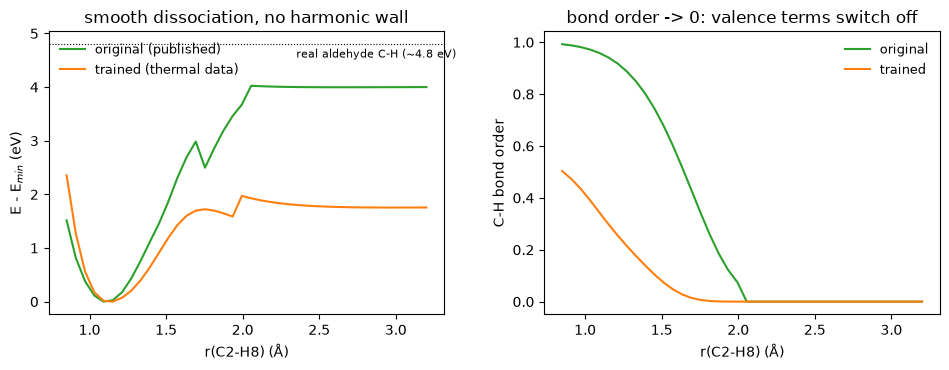

original field: D(C-H) plateau ~ 4.00 eV (parameterized on bond-breaking data; a real aldehyde C-H is ~4.8 eV)
trained field : D(C-H) plateau ~ 1.76 eV (an extrapolation: no stretched bonds in the training data)


In [5]:
c_atom, h_atom = 2, 8                      # the aldehyde C-H of C2
u = pos0[h_atom] - pos0[c_atom]
u /= np.linalg.norm(u)
rs = np.linspace(0.85, 3.2, 40)


def scan(m):
    es, bos = [], []
    for r in rs:
        p = pos0.copy()
        p[h_atom] = pos0[c_atom] + u * r
        g = structure_to_graph({"pos": p, "atomic_numbers": z},
                               cutoff=m.cutoff)
        es.append(float(m(g)["energy"][0]))
        it = m.intermediates
        bm = it["bond_mask"]
        sel = (g.edge_index[1][bm] == c_atom) & (g.edge_index[0][bm] == h_atom)
        bos.append(float(it["bo0"][sel][0]) if bool(sel.any()) else 0.0)
    es = np.array(es)
    return es - es.min(), np.array(bos)


e_trained, bo_trained = scan(model)
e_orig, bo_orig = scan(orig_model)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.8))
axes[0].plot(rs, e_orig, color="C2", label="original (published)")
axes[0].plot(rs, e_trained, color="C1", label="trained (thermal data)")
axes[0].axhline(4.8, color="k", ls=":", lw=0.8)
axes[0].text(2.35, 4.55, "real aldehyde C-H (~4.8 eV)", fontsize=8)
axes[0].set_xlabel("r(C2-H8) (Å)")
axes[0].set_ylabel("E - E$_{min}$ (eV)")
axes[0].set_title("smooth dissociation, no harmonic wall")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
axes[1].plot(rs, bo_orig, color="C2", label="original")
axes[1].plot(rs, bo_trained, color="C1", label="trained")
axes[1].set_xlabel("r(C2-H8) (Å)")
axes[1].set_ylabel("C-H bond order")
axes[1].set_title("bond order -> 0: valence terms switch off")
axes[1].legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("reaxff_bond_dissociation.png", dpi=150)
plt.show()

print(f"original field: D(C-H) plateau ~ {e_orig[-1]:.2f} eV "
      f"(parameterized on bond-breaking data; a real aldehyde C-H is ~4.8 eV)")
print(f"trained field : D(C-H) plateau ~ {e_trained[-1]:.2f} eV "
      f"(an extrapolation: no stretched bonds in the training data)")

## Summary

* One forward pass of `ReaxFF` yields, besides energies/forces, the full set
  of **reactive descriptors**: per-pair bond orders, per-atom EEM charges,
  and the complete per-term energy decomposition (`e_bond`, `e_angle`,
  `e_vdw`, ...).
* Any ReaxFF parameter library runs **ASE molecular dynamics** through
  `XNNCalculator` (relax first, use the standard 0.1 fs ReaxFF timestep),
  with bond orders cleanly separating double from single bonds along the
  trajectory and charges fluctuating with the geometry.
* Bond breaking is **smooth by construction** — but its energetics (and
  off-manifold dynamics) are only as good as the training data. Extending
  the training set with stretch and reaction-path configurations, as the
  ReaxFF-nn papers do, is what pins them.
* The **original classical ReaxFF** runs in the same class straight from a
  published `ffield` text file, and the comparison cuts both ways: on this
  molecule's thermal data it is roughly an order of magnitude less accurate
  than the trained field (see the training notebook), yet on the
  dissociation coordinate its combustion parameterization gives the
  physically sized well the trained field cannot know.